# Basic KMeans (only mean x and y)

In [2]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns

Using 50 tracking files
Players with enough data: 534


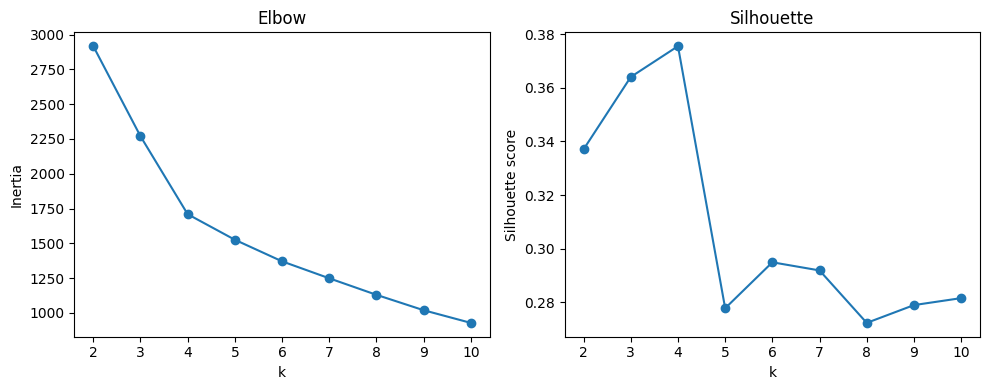


--- Cluster characteristics (mean per feature) ---



mean_x          mean_y            std_x            std_y          \
           mean     std    mean     std     mean     std     mean     std   
cluster                                                                     
0       -9.2035  5.9831 -0.3986  6.8409  21.4537  3.1883  12.3189  2.5649   
1        0.0361  2.1243 -0.6910  3.9047  22.9728  2.0243  14.5046  2.6404   
2        0.0596  2.4473 -0.2519  0.3355  39.5133  2.1584   3.9194  0.4130   
3        8.2343  5.3175 -1.2864  7.0828  21.1061  2.5901  11.9344  2.5400   

        total_distance            pct_attacking_half         pct_own_half  \
                  mean        std               mean     std         mean   
cluster                                                                     
0            4275.0749  2316.9763             0.3348  0.0852       0.6650   
1            7925.7458  1943.1430             0.4997  0.0418       0.5001   
2            4080.9426   241.7387             0.5028  0.0262       0.4972   
3            3718.6373  1936.1052             0.6498  0.0889       0.3501   

                 
            std  
cluster          
0        0.0853  
1        0.0418  
2        0.0262  
3        0.0889

In [6]:
# --- Config: load data path and limit matches for speed (set to None to use all) ---
import json
from pathlib import Path

with open("creds/gdrive_folder.json", "r") as f:
    gdrive_data_folder_path = json.load(f)["data_folder_path"]

tracking_dir = Path(gdrive_data_folder_path + "skillcorner/tracking")
tracking_files = list(tracking_dir.glob("*.json"))
max_matches = 50  # Use first 50 matches; set to None to use all
if max_matches:
    tracking_files = tracking_files[:max_matches]

print(f"Using {len(tracking_files)} tracking files")

def extract_player_features_from_match(file_path):
    """Load one tracking JSON and return a DataFrame of per-player features for that match."""
    with open(file_path, "r") as f:
        frames = json.load(f)

    match_id = int(Path(file_path).stem.split("-")[-1])

    # Collect time series per player: list of (x, y) per frame
    from collections import defaultdict
    player_positions = defaultdict(list)

    for frame in frames:
        for p in frame.get("player_data", []):
            x, y = p.get("x"), p.get("y")
            if x is None or y is None:
                continue
            pid = p.get("player_id")
            if pid is None:
                continue
            player_positions[pid].append((float(x), float(y)))

    # Build features per player
    rows = []
    for player_id, positions in player_positions.items():
        if len(positions) < 10:
            continue
        arr = np.array(positions)
        x_vals = arr[:, 0]
        y_vals = arr[:, 1]

        # Displacement frame-to-frame (approximate distance covered)
        diffs = np.diff(arr, axis=0)
        distances = np.sqrt((diffs[:, 0] ** 2) + (diffs[:, 1] ** 2))
        total_distance = float(np.sum(distances))

        rows.append({
            "match_id": match_id,
            "player_id": player_id,
            "mean_x": float(np.mean(x_vals)),
            "mean_y": float(np.mean(y_vals)),
            "std_x": float(np.std(x_vals)),
            "std_y": float(np.std(y_vals)),
            "total_distance": total_distance,
            "n_frames": len(positions),
            "pct_attacking_half": float(np.mean(x_vals > 0)),
            "pct_own_half": float(np.mean(x_vals < 0)),
        })

    return pd.DataFrame(rows)

# Build feature table: one row per (match_id, player_id)
feature_dfs = []
for i, fp in enumerate(tracking_files):
    try:
        df = extract_player_features_from_match(fp)
        if len(df) > 0:
            feature_dfs.append(df)
    except Exception as e:
        print(f"Skip {fp.name}: {e}")

player_match_features = pd.concat(feature_dfs, ignore_index=True)

# Aggregate per player (average across matches) for clustering
player_features = (
    player_match_features.groupby("player_id")
    .agg({
        "mean_x": "mean",
        "mean_y": "mean",
        "std_x": "mean",
        "std_y": "mean",
        "total_distance": "mean",
        "n_frames": "sum",
        "pct_attacking_half": "mean",
        "pct_own_half": "mean",
        "match_id": "nunique",
    })
    .rename(columns={"match_id": "n_matches"})
    .reset_index()
)

# Drop players with too few frames (noise)
player_features = player_features[player_features["n_frames"] >= 500].copy()
print(f"Players with enough data: {len(player_features)}")

# Feature matrix for clustering (exclude ids and count columns)
feature_cols = ["mean_x", "mean_y", "std_x", "std_y", "total_distance", "pct_attacking_half", "pct_own_half"]
X = player_features[feature_cols].copy()
X = X.fillna(X.median())

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Elbow / silhouette to choose k
inertias = []
silhouettes = []
K_range = range(2, 11)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, km.labels_))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
ax1.plot(list(K_range), inertias, "o-")
ax1.set_xlabel("k")
ax1.set_ylabel("Inertia")
ax1.set_title("Elbow")
ax2.plot(list(K_range), silhouettes, "o-")
ax2.set_xlabel("k")
ax2.set_ylabel("Silhouette score")
ax2.set_title("Silhouette")
plt.tight_layout()
plt.show()

# Fit final model (k=5 is a reasonable default; change as you prefer)
n_clusters = 4
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
player_features["cluster"] = kmeans.fit_predict(X_scaled)

# Cluster breakdown: mean (and std) of each feature per cluster
print("\n--- Cluster characteristics (mean per feature) ---\n")
breakdown = player_features.groupby("cluster")[feature_cols].agg(["mean", "std"])
breakdown.round(4)

In [8]:
# Cluster breakdown for labeling
breakdown = player_features.groupby("cluster")[feature_cols].agg(["mean", "std"]).round(4)
display(breakdown)

# Summary interpretation (use these to assign role labels)
print("\n--- Feature meaning ---")
print("mean_x: average position along pitch (-52 to +52; negative = own half)")
print("mean_y: average lateral position (-34 to +34)")
print("std_x, std_y: how much they move in each direction")
print("total_distance: distance covered per match (m)")
print("pct_attacking_half: share of time with x > 0")
print("pct_own_half: share of time with x < 0")
print("\n--- Suggested labels (inspect breakdown above and rename) ---")
for c in sorted(player_features["cluster"].unique()):
    sub = player_features[player_features["cluster"] == c]
    mx = sub["mean_x"].mean()
    md = sub["total_distance"].mean()
    print(f"  Cluster {c}: n={len(sub)} | mean_x≈{mx:.1f} | total_distance≈{md:.0f}m → e.g. 'defender' / 'midfielder' / 'forward' / 'wide' / 'central'")

mean_x          mean_y            std_x            std_y          \
           mean     std    mean     std     mean     std     mean     std   
cluster                                                                     
0       -9.2035  5.9831 -0.3986  6.8409  21.4537  3.1883  12.3189  2.5649   
1        0.0361  2.1243 -0.6910  3.9047  22.9728  2.0243  14.5046  2.6404   
2        0.0596  2.4473 -0.2519  0.3355  39.5133  2.1584   3.9194  0.4130   
3        8.2343  5.3175 -1.2864  7.0828  21.1061  2.5901  11.9344  2.5400   

        total_distance            pct_attacking_half         pct_own_half  \
                  mean        std               mean     std         mean   
cluster                                                                     
0            4275.0749  2316.9763             0.3348  0.0852       0.6650   
1            7925.7458  1943.1430             0.4997  0.0418       0.5001   
2            4080.9426   241.7387             0.5028  0.0262       0.4972   
3            3718.6373  1936.1052             0.6498  0.0889       0.3501   

                 
            std  
cluster          
0        0.0853  
1        0.0418  
2        0.0262  
3        0.0889


--- Feature meaning ---
mean_x: average position along pitch (-52 to +52; negative = own half)
mean_y: average lateral position (-34 to +34)
std_x, std_y: how much they move in each direction
total_distance: distance covered per match (m)
pct_attacking_half: share of time with x > 0
pct_own_half: share of time with x < 0

--- Suggested labels (inspect breakdown above and rename) ---
  Cluster 0: n=84 | mean_x≈-9.2 | total_distance≈4275m → e.g. 'defender' / 'midfielder' / 'forward' / 'wide' / 'central'
  Cluster 1: n=338 | mean_x≈0.0 | total_distance≈7926m → e.g. 'defender' / 'midfielder' / 'forward' / 'wide' / 'central'
  Cluster 2: n=34 | mean_x≈0.1 | total_distance≈4081m → e.g. 'defender' / 'midfielder' / 'forward' / 'wide' / 'central'
  Cluster 3: n=78 | mean_x≈8.2 | total_distance≈3719m → e.g. 'defender' / 'midfielder' / 'forward' / 'wide' / 'central'


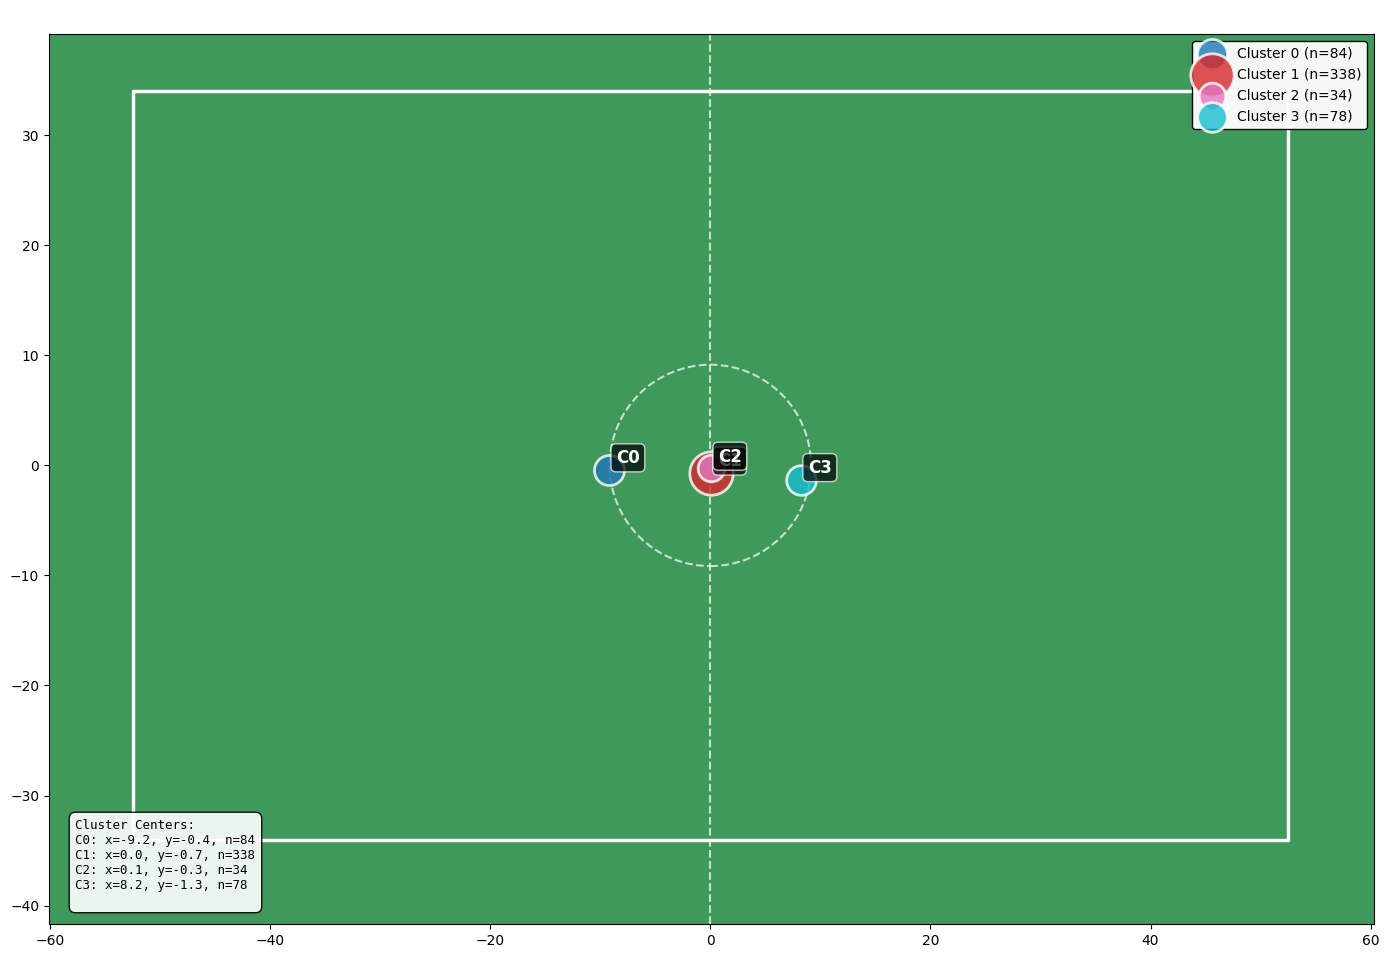

In [12]:
# Plot cluster centers on the pitch
from src.pitch import create_pitch

# Calculate cluster centers (mean of mean_x, mean_y per cluster)
cluster_centers = player_features.groupby("cluster")[["mean_x", "mean_y"]].mean().reset_index()

# Create figure with pitch
fig, ax = plt.subplots(figsize=(14, 10))
create_pitch(ax, title="KMeans Cluster Centers on Pitch")

# Color palette for clusters
colors = plt.cm.tab10(np.linspace(0, 1, n_clusters))

# Plot cluster centers
for idx, row in cluster_centers.iterrows():
    cluster_id = int(row["cluster"])
    x = row["mean_x"]
    y = row["mean_y"]
    
    # Get cluster size for marker size
    cluster_size = len(player_features[player_features["cluster"] == cluster_id])
    
    ax.scatter(
        x, y,
        s=300 + cluster_size * 2,  # Size proportional to cluster size
        c=[colors[cluster_id]],
        edgecolors="white",
        linewidths=2,
        zorder=10,
        alpha=0.8,
        label=f"Cluster {cluster_id} (n={cluster_size})"
    )
    
    # Add cluster label
    ax.annotate(
        f"C{cluster_id}",
        (x, y),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=12,
        weight="bold",
        color="white",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="black", alpha=0.7, edgecolor="white"),
        zorder=11
    )

# Add legend
ax.legend(
    loc="upper right",
    facecolor="white",
    framealpha=0.95,
    fontsize=10,
    edgecolor="black",
    frameon=True
)

# Add text box with cluster characteristics
info_text = "Cluster Centers:\n"
for idx, row in cluster_centers.iterrows():
    cluster_id = int(row["cluster"])
    sub = player_features[player_features["cluster"] == cluster_id]
    info_text += f"C{cluster_id}: x={row['mean_x']:.1f}, y={row['mean_y']:.1f}, n={len(sub)}\n"

ax.text(
    0.02, 0.02,
    info_text,
    transform=ax.transAxes,
    fontsize=9,
    verticalalignment="bottom",
    bbox=dict(boxstyle="round,pad=0.5", facecolor="white", alpha=0.9, edgecolor="black"),
    family="monospace"
)

plt.tight_layout()
plt.show()

In [11]:
import json
from pathlib import Path
import numpy as np
import pandas as pd

# Load one match's tracking data
with open("creds/gdrive_folder.json", "r") as f:
    gdrive_data_folder_path = json.load(f)["data_folder_path"]

tracking_file = Path(gdrive_data_folder_path + "skillcorner/tracking/tracking_usl_championship-2025-2006551.json")

with open(tracking_file, "r") as f:
    frames = json.load(f)

period_1_frames = [f for f in frames if f.get("period") == 1]
period_2_frames = [f for f in frames if f.get("period") == 2]

# Collect ALL players' mean_x in each period
player_x_p1 = {}
player_x_p2 = {}

for frame in period_1_frames:
    for p in frame.get("player_data", []):
        pid = p.get("player_id")
        x = p.get("x")
        if pid is not None and x is not None:
            if pid not in player_x_p1:
                player_x_p1[pid] = []
            player_x_p1[pid].append(x)

for frame in period_2_frames:
    for p in frame.get("player_data", []):
        pid = p.get("player_id")
        x = p.get("x")
        if pid is not None and x is not None:
            if pid not in player_x_p2:
                player_x_p2[pid] = []
            player_x_p2[pid].append(x)

# Calculate mean_x per player per period
common_players = set(player_x_p1.keys()) & set(player_x_p2.keys())
comparisons = []

for pid in list(common_players)[:22]:  # Sample 22 players (full team)
    if len(player_x_p1[pid]) > 100 and len(player_x_p2[pid]) > 100:
        mean_p1 = np.mean(player_x_p1[pid])
        mean_p2 = np.mean(player_x_p2[pid])
        comparisons.append({
            "player_id": pid,
            "mean_x_p1": mean_p1,
            "mean_x_p2": mean_p2,
            "difference": mean_p2 - mean_p1,
            "flipped": mean_p2 - mean_p1  # Will calculate if flipped
        })

comp_df = pd.DataFrame(comparisons)

# Check ball position too
ball_x_p1 = [f.get("ball_data", {}).get("x") for f in period_1_frames if f.get("ball_data", {}).get("x") is not None]
ball_x_p2 = [f.get("ball_data", {}).get("x") for f in period_2_frames if f.get("ball_data", {}).get("x") is not None]

print("=== Player Position Analysis ===")
print(f"\nPlayers analyzed: {len(comp_df)}")
print(f"\nMean x-coordinate shift (Period 2 - Period 1):")
print(f"  Mean shift: {comp_df['difference'].mean():.2f}")
print(f"  Std shift: {comp_df['difference'].std():.2f}")
print(f"\nIf teams switch sides, we'd expect:")
print(f"  - Mean shift close to ~30 (full flip)")
print(f"  - All players shift in same direction")

print(f"\n=== Ball Position ===")
if len(ball_x_p1) > 0 and len(ball_x_p2) > 0:
    ball_mean_p1 = np.mean(ball_x_p1)
    ball_mean_p2 = np.mean(ball_x_p2)
    print(f"Ball mean_x Period 1: {ball_mean_p1:.2f}")
    print(f"Ball mean_x Period 2: {ball_mean_p2:.2f}")
    print(f"Ball shift: {ball_mean_p2 - ball_mean_p1:.2f}")

print(f"\n=== Verdict ===")
mean_shift = comp_df['difference'].mean()
if abs(mean_shift) > 20 and comp_df['difference'].std() < 10:
    print("✓ Teams SWITCH sides (all players shift ~same amount)")
elif abs(mean_shift) < 5:
    print("✓ Teams STAY on same side (minimal shift)")
else:
    print("? Ambiguous - players may have different roles/positions")
    print("  Check individual player shifts:")
    print(comp_df[['player_id', 'mean_x_p1', 'mean_x_p2', 'difference']].head(10))

=== Player Position Analysis ===

Players analyzed: 20

Mean x-coordinate shift (Period 2 - Period 1):
  Mean shift: 13.87
  Std shift: 32.90

If teams switch sides, we'd expect:
  - Mean shift close to ~30 (full flip)
  - All players shift in same direction

=== Ball Position ===
Ball mean_x Period 1: -15.89
Ball mean_x Period 2: 6.52
Ball shift: 22.41

=== Verdict ===
? Ambiguous - players may have different roles/positions
  Check individual player shifts:
   player_id  mean_x_p1  mean_x_p2  difference
0     721152 -14.977693   4.455849   19.433542
1       7948  -4.299487  -2.146884    2.152603
2      30483 -23.775615  13.681467   37.457082
3      44186   5.915107 -12.630558  -18.545665
4     333595  34.012556 -37.533539  -71.546095
5     333730 -21.524998  11.102253   32.627251
6     814501  -3.791168  -1.751861    2.039307
7     333616 -44.223116  39.565228   83.788344
8     710448 -34.234146  16.972921   51.207067
9      28980 -24.172769  10.819847   34.992615
